<a href="https://colab.research.google.com/github/emiliomartineziteso/sim-mat/blob/main/Repaso_M%C3%B3dulo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Repaso - Módulo 2

## Problema 1. Simulación Montecarlo usando Caminata aleatoria

Se desea conocer el estado final de un proceso hipotético definido como una Máquina de estados. Este proceso cuenta con los estados: **A** y **B**. El proceso se define de la siguiente manera:
* Estando en el estado **A**, 4 de cada 7 operaciones cambia al estado **B**, el resto de casos se mantiene en el estado **A**.
* Estando en el estado **B**, 1 de cada 3 operaciones cambia al estado **A**, el resto de casos se mantiene en el estado **B**.

Respresentado por el siguiente diagrama

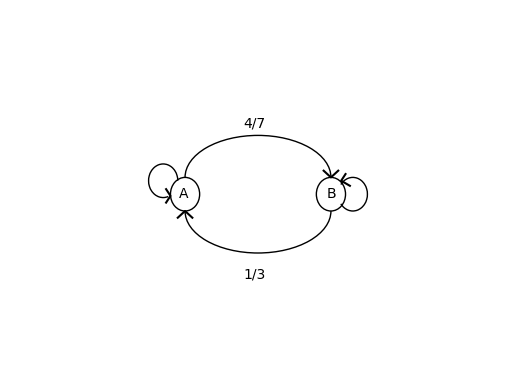

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

C1 = patches.Circle((-0.5, 0), 0.1,fc='None',color='k')
C2 = patches.Circle((0.5, 0), 0.1,fc='None',color='k')
B1 = patches.Arc((0, 0.1), 1,0.5,theta2=180,fc='None',color='k')
B2 = patches.Arc((0, -0.1), 1,0.5,theta1=180,fc='None',color='k')
A1 = patches.Arc((-0.65, 0.08), 0.2,0.2,theta2=290,fc='None',color='k')
A2 = patches.Arc((0.65, 0), 0.2,0.2,theta1=-145,theta2=145,fc='None',color='k')
ax = plt.gca()
ax.add_artist(B1)
ax.add_artist(B2)
ax.add_artist(C1)
ax.add_artist(C2)
ax.add_artist(A1)
ax.add_artist(A2)

plt.plot([0.45,0.5,0.55],[0.14,0.1,0.14],'k')
plt.plot([-0.45,-0.5,-0.55],[-0.14,-0.1,-0.14],'k')
plt.plot([-0.63,-0.6,-0.63],[0.03,-0.01,-0.05],'k')
plt.plot([0.63,0.57,0.6],[0.05,0.08,0.12],'k')

plt.text(-0.54,-0.02,'A')
plt.text(0.47,-0.02,'B')
plt.text(-0.1,0.4,'4/7')
plt.text(-0.1,-0.5,'1/3')

plt.axis([-1.7,1.7,-1.1,1.1])
plt.axis('off')
plt.show()

* Si el proceso parte del estado **A**, y se ejecutan 50 operaciones, ¿Cuál es la probabilidad de que el proceso finalice en el estado **B**? Usando el método Montecarlo con 100000 escenarios.

In [3]:

n_sims = 100000     # Número de simulaciones
n_steps = 50        # Número de operaciones
p_A_to_B = 4/7      # Probabilidad de pasar de A a B
p_B_to_A = 1/3      # Probabilidad de pasar de B a A

# --- Inicialización ---
# 0 = A, 1 = B
states = np.zeros(n_sims, dtype=np.int8)  # Todos inician en A

# Generador aleatorio (puedes cambiar la semilla si quieres resultados distintos)
rng = np.random.default_rng(12345)

# --- Simulación Montecarlo ---
for _ in range(n_steps):
    u = rng.random(n_sims)

    # Quienes están en A cambian a B con probabilidad 4/7
    idx_A = (states == 0)
    change_to_B = (u < p_A_to_B) & idx_A

    # Quienes están en B cambian a A con probabilidad 1/3
    idx_B = (states == 1)
    change_to_A = (u < p_B_to_A) & idx_B

    # Actualizar estados
    states[change_to_B] = 1
    states[change_to_A] = 0

# --- Resultados finales ---
count_B = states.sum()
prob_B = count_B / n_sims

# Intervalo de confianza del 95%
se = np.sqrt(prob_B * (1 - prob_B) / n_sims)
ci_low = prob_B - 1.96 * se
ci_high = prob_B + 1.96 * se

# --- Mostrar resultados ---
print(f"Simulaciones: {n_sims:,}")
print(f"Operaciones por simulación: {n_steps}")
print(f"Probabilidad estimada de terminar en B: {prob_B:.6f} ({count_B} de {n_sims})")
print(f"IC 95% aproximado: [{ci_low:.6f}, {ci_high:.6f}]")



Simulaciones: 100,000
Operaciones por simulación: 50
Probabilidad estimada de terminar en B: 0.632530 (63253 de 100000)
IC 95% aproximado: [0.629542, 0.635518]


---
## Problema 2. Simulación de escenarios futuros

Evaluaremos dos compañías con tendencias más o menos similares (Apple y Microsoft) veremos cuál tiene más probabilidades de darnos un interés deseado.

Además, descargaremos los datos del año 2025 para ver si el análisis concuerda.

Descargue datos para Apple y Microsoft desde enero de 2015 a diciembre de 2024 y muestre sus gráficas.

[*********************100%***********************]  2 of 2 completed


Archivos guardados: AAPL_2015_2024.csv, MSFT_2015_2024.csv

Primeras filas (AAPL):
Date
2015-01-02    24.261045
2015-01-05    23.577578
2015-01-06    23.579794
2015-01-07    23.910437
2015-01-08    24.829124
Name: AAPL, dtype: float64

Primeras filas (MSFT):
Date
2015-01-02    39.933067
2015-01-05    39.565845
2015-01-06    38.985119
2015-01-07    39.480419
2015-01-08    40.641872
Name: MSFT, dtype: float64


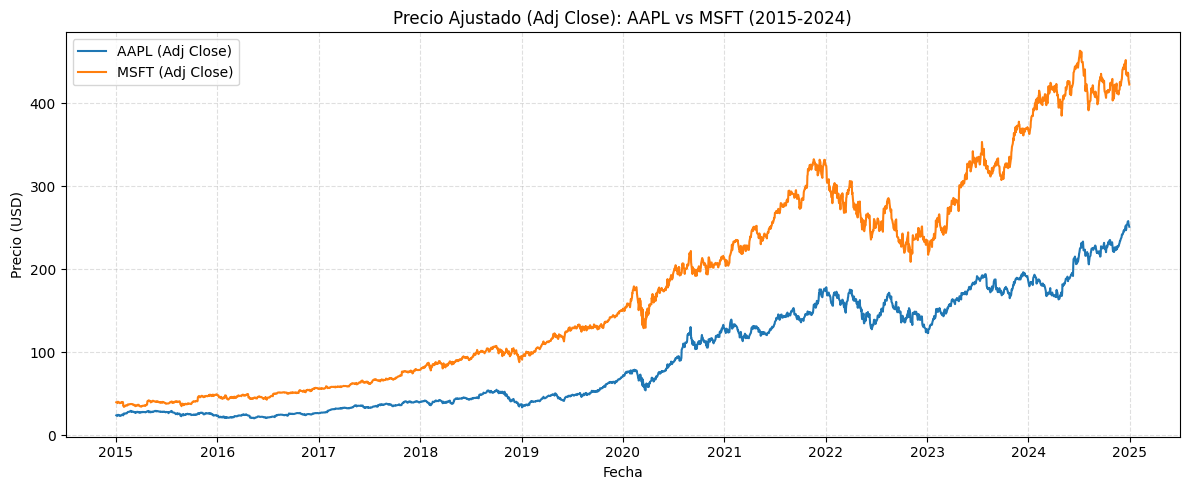

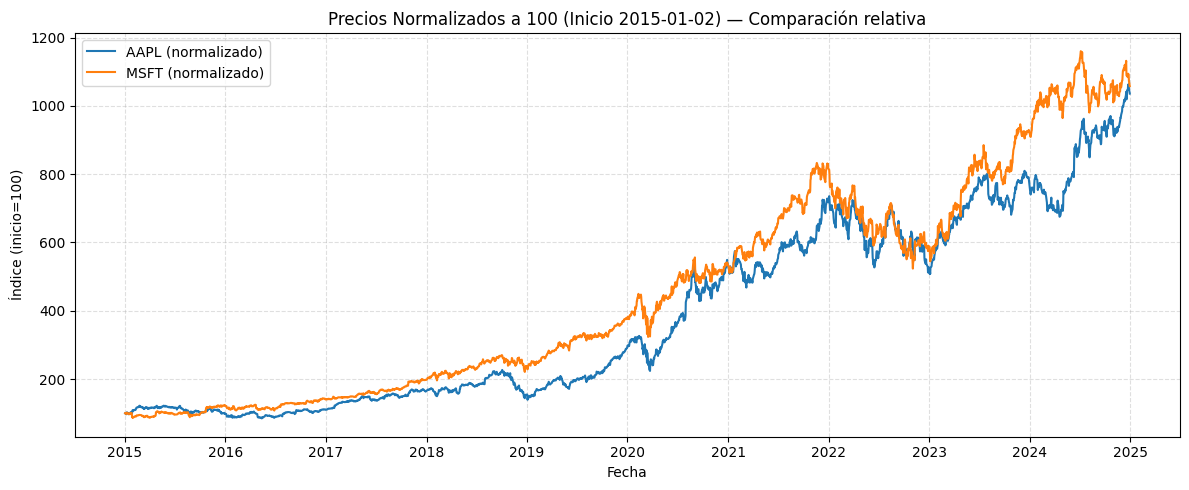


Estadísticas (Adj Close) — AAPL:


,count,mean,std,min,25%,50%,75%,max
AAPL,2515.0,93.888059,65.444203,20.62405,35.237459,64.436157,150.365341,258.103729



Estadísticas (Adj Close) — MSFT:


,count,mean,std,min,25%,50%,75%,max
MSFT,2515.0,180.918091,123.121214,34.501614,64.75993,145.770813,275.189575,463.240936



Guardado CSV combinado: AAPL_MSFT_adjclose_2015_2024.csv


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros
tickers = ['AAPL', 'MSFT']
start = '2015-01-01'
end = '2024-12-31'   # incluye hasta 31-dic-2024

# Descargar datos (Daily by default)
data = yf.download(tickers, start=start, end=end, progress=True, auto_adjust=False)

# 'Adj Close' es lo recomendado para análisis ajustado por dividendos/splits
adj_close = data['Adj Close'].copy()
adj_close.columns = tickers

# Guardar CSVs individuales
adj_close['AAPL'].to_csv('AAPL_2015_2024.csv', index=True)
adj_close['MSFT'].to_csv('MSFT_2015_2024.csv', index=True)
print("Archivos guardados: AAPL_2015_2024.csv, MSFT_2015_2024.csv\n")

# Mostrar primeras filas
print("Primeras filas (AAPL):")
print(adj_close['AAPL'].head())
print("\nPrimeras filas (MSFT):")
print(adj_close['MSFT'].head())

# --- Gráfica 1: Series temporales de precio ajustado ---
plt.figure(figsize=(12,5))
plt.plot(adj_close.index, adj_close['AAPL'], label='AAPL (Adj Close)')
plt.plot(adj_close.index, adj_close['MSFT'], label='MSFT (Adj Close)')
plt.title('Precio Ajustado (Adj Close): AAPL vs MSFT (2015-2024)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Gráfica 2: Precios normalizados a 100 al inicio (comparar tendencia relativa) ---
norm = adj_close / adj_close.iloc[0] * 100

plt.figure(figsize=(12,5))
plt.plot(norm.index, norm['AAPL'], label='AAPL (normalizado)')
plt.plot(norm.index, norm['MSFT'], label='MSFT (normalizado)')
plt.title('Precios Normalizados a 100 (Inicio 2015-01-02) — Comparación relativa')
plt.xlabel('Fecha')
plt.ylabel('Índice (inicio=100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Estadísticas descriptivas rápidas ---
print("\nEstadísticas (Adj Close) — AAPL:")
display(adj_close['AAPL'].describe().to_frame().T)
print("\nEstadísticas (Adj Close) — MSFT:")
display(adj_close['MSFT'].describe().to_frame().T)

# --- Opcional: guardar un CSV combinado ---
adj_close.to_csv('AAPL_MSFT_adjclose_2015_2024.csv')
print("\nGuardado CSV combinado: AAPL_MSFT_adjclose_2015_2024.csv")


Calcule los rendimientos diarios junto con sus características estadísticas

In [5]:
# --- Rendimientos diarios y estadísticas ---
returns = adj_close.pct_change().dropna()
print("Rendimientos diarios (primeras filas):")
print(returns.head(), "\n")

# Estadísticas básicas
stats = returns.describe().T
stats['varianza'] = returns.var().values
stats['volatilidad'] = returns.std().values
display(stats[['mean','std','min','max','25%','50%','75%','varianza','volatilidad']])


Rendimientos diarios (primeras filas):
                AAPL      MSFT
Date                          
2015-01-05 -0.028171 -0.009196
2015-01-06  0.000094 -0.014677
2015-01-07  0.014022  0.012705
2015-01-08  0.038422  0.029418
2015-01-09  0.001073 -0.008405 



,mean,std,min,max,25%,50%,75%,varianza,volatilidad
AAPL,0.001091,0.017932,-0.128647,0.119808,-0.007328,0.001001,0.010144,0.000322,0.017932
MSFT,0.001085,0.017098,-0.147391,0.142169,-0.006728,0.000958,0.009780,0.000292,0.017098


Simule 10000 escenarios de rendimientos diarios para todo el año 2025 (para cada una de las empresas).

In [6]:
# --- Simulación Montecarlo de rendimientos 2025 ---
n, days = 10000, 252
sim = {t: np.random.normal(returns[t].mean(), returns[t].std(), (days, n)) for t in returns.columns}
print("Simulación completada: 10,000 escenarios de 252 días para cada empresa.")


Simulación completada: 10,000 escenarios de 252 días para cada empresa.


Calcule los precios con base en los rendimientos simulados

Precios simulados para 2025 generados (shape: (252, 10000) )

AAPL - Precio inicial: 251.31 | Promedio final simulado: 330.85


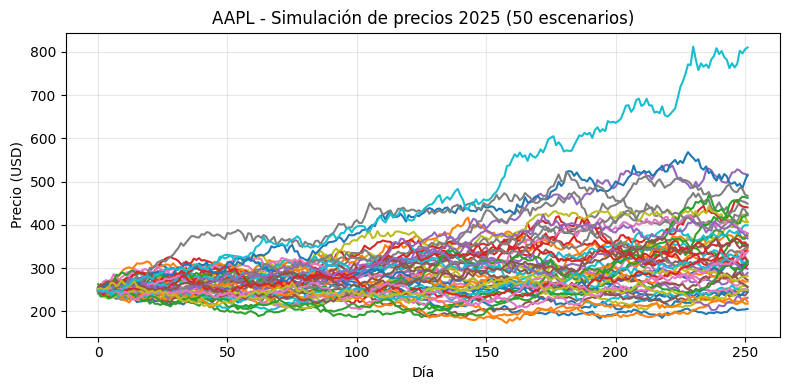


MSFT - Precio inicial: 422.51 | Promedio final simulado: 555.41


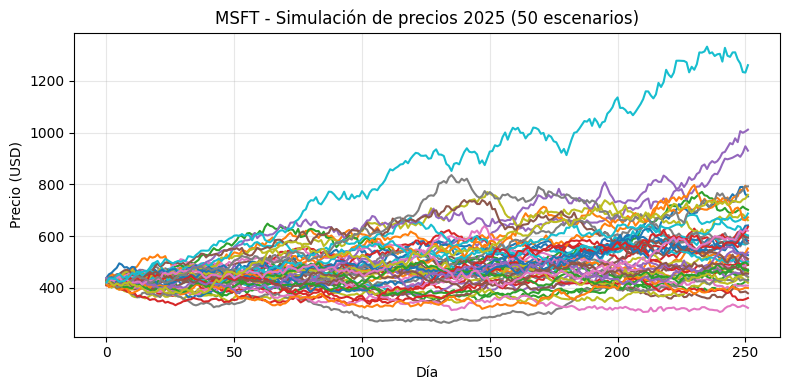

In [8]:
# --- Cálculo de precios simulados para 2025 ---
last = adj_close.iloc[-1]  # último precio de 2024
prices = {t: last[t] * (1 + sim[t]).cumprod(axis=0) for t in sim}
print("Precios simulados para 2025 generados (shape:", prices['AAPL'].shape, ")")
# --- Mostrar precios simulados ---
for t in prices:
    print(f"\n{t} - Precio inicial: {last[t]:.2f} | Promedio final simulado: {prices[t][-1].mean():.2f}")
    plt.figure(figsize=(8,4))
    plt.plot(prices[t][:, :50])  # mostrar 50 trayectorias
    plt.title(f"{t} - Simulación de precios 2025 (50 escenarios)")
    plt.xlabel("Día")
    plt.ylabel("Precio (USD)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Calcule la probabilidad de obtener un retorno del 20% para ambas marcas.

In [9]:
# --- Probabilidad de obtener un retorno >= 20% ---
for t in prices:
    ret = prices[t][-1] / last[t] - 1
    p20 = np.mean(ret >= 0.20)
    print(f"Probabilidad de retorno ≥ 20% en 2025 para {t}: {p20:.2%}")


Probabilidad de retorno ≥ 20% en 2025 para AAPL: 57.08%
Probabilidad de retorno ≥ 20% en 2025 para MSFT: 57.70%


Finalmente, grafique los datos reales del 2025 para ver que tan acertado fue nuestro análisis.

[*********************100%***********************]  2 of 2 completed


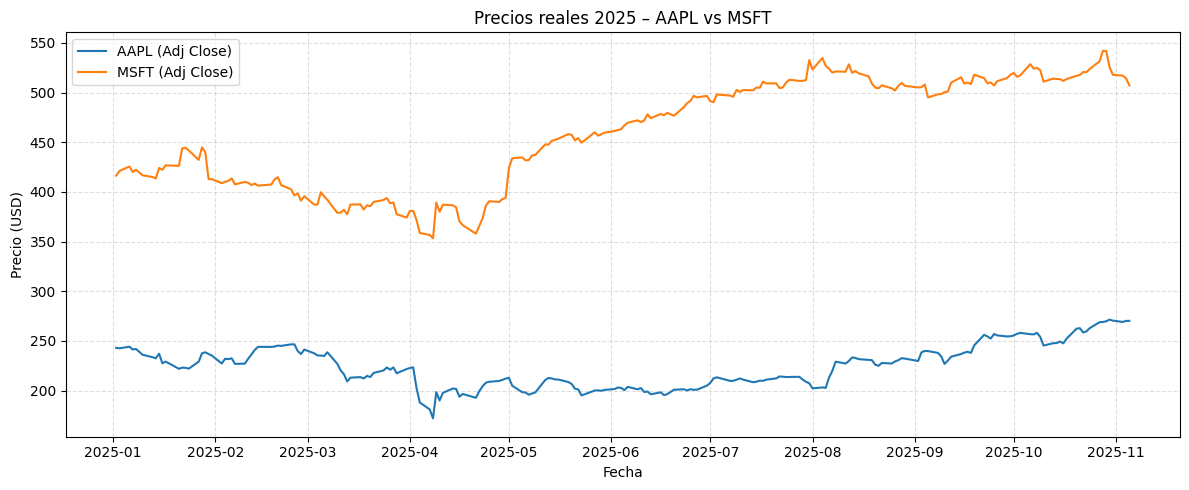

In [10]:
# --- Descargar datos reales 2025 y graficar ---
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ['AAPL', 'MSFT']
data25 = yf.download(tickers, start='2025-01-01', end='2025-12-31', auto_adjust=False)['Adj Close']
plt.figure(figsize=(12,5))
for t in tickers:
    plt.plot(data25.index, data25[t], label=f'{t} (Adj Close)')
plt.title('Precios reales 2025 – AAPL vs MSFT')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
